# 03. Извлечение признаков из аудио

Цель этапа: превратить аудиозаписи фрезерования в таблицу числовых признаков, которую можно подать в модели машинного обучения.

На выходе создается файл `data/processed/features.csv`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

print("Корень проекта:", PROJECT_ROOT)
print("Обработанные данные:", DATA_PROCESSED)
print("Папка с графиками:", FIGURES_DIR)

Корень проекта: C:\Users\ivan.kopytin\Desktop\уник\surface_roughness_project
Обработанные данные: C:\Users\ivan.kopytin\Desktop\уник\surface_roughness_project\data\processed
Папка с графиками: C:\Users\ivan.kopytin\Desktop\уник\surface_roughness_project\reports\figures


## 1. Загружаем метаданные

Используем таблицу `metadata.csv`, которую собрали на предыдущем этапе.


In [2]:
metadata = pd.read_csv(DATA_PROCESSED / "metadata.csv")

print("Размер metadata:", metadata.shape)
print("Уникальных режимов:", metadata["condition_id"].nunique())
print("Пропуски в roughness_ra:", metadata["roughness_ra"].isna().sum())

display(metadata[["condition_id", "run_id", "feed_mm", "speed_rpm", "depth_mm", "roughness_ra", "aup_path"]].head())

Размер metadata: (319, 30)
Уникальных режимов: 16
Пропуски в roughness_ra: 0


,condition_id,run_id,feed_mm,speed_rpm,depth_mm,roughness_ra,aup_path
0,f5_s250_d0.25,1,5.0,250,0.25,1.57,data/raw/Milling Surface Roughness Acoustic Se...
1,f5_s250_d0.25,2,5.0,250,0.25,1.57,data/raw/Milling Surface Roughness Acoustic Se...
2,f5_s250_d0.25,3,5.0,250,0.25,1.57,data/raw/Milling Surface Roughness Acoustic Se...
3,f5_s250_d0.25,4,5.0,250,0.25,1.57,data/raw/Milling Surface Roughness Acoustic Se...
4,f5_s250_d0.25,5,5.0,250,0.25,1.57,data/raw/Milling Surface Roughness Acoustic Se...


## 2. Извлекаем акустические признаки

Признаки делятся на три группы:

- признаки из XML-блоков Audacity: RMS, пики, динамический диапазон;
- статистика выбранных аудио-фрагментов: среднее, RMS, crest factor, zero crossing rate;
- спектральные признаки: спектральный центр, ширина, rolloff, энергия в частотных диапазонах.


In [3]:
from features import build_feature_table

features_path = DATA_PROCESSED / "features.csv"
features = build_feature_table(
    metadata=metadata,
    project_root=PROJECT_ROOT,
    output_path=features_path,
    max_blocks_per_track=6,
    progress_every=25,
)

print("Файл с признаками сохранен:", features_path)
print("Размер features:", features.shape)
display(features.head())

Processed 25/319 audio projects


Processed 50/319 audio projects


Processed 75/319 audio projects


Processed 100/319 audio projects


Processed 125/319 audio projects


...

Processed 250/319 audio projects


Processed 275/319 audio projects


Processed 300/319 audio projects


Processed 319/319 audio projects
Файл с признаками сохранен: C:\Users\ivan.kopytin\Desktop\уник\surface_roughness_project\data\processed\features.csv
Размер features: (319, 42)


,condition_id,feed_mm,speed_rpm,depth_mm,run_id,roughness_ra,sample_rate_hz,channels,duration_sec,selected_samples,...,spec_bandwidth_hz,spec_rolloff85_hz,spec_flatness,spec_dominant_hz,spec_power_total,spec_power_0_500,spec_power_500_2000,spec_power_2000_8000,spec_power_8000_plus,spec_high_to_low_ratio
0,f5_s250_d0.25,5.0,250,0.25,1,1.57,44100.0,2.0,61.445805,1399040.0,...,959.203282,1647.290039,0.006804,48.449707,0.012955,0.003926,0.007526,0.001482,0.000011,0.130338
1,f5_s250_d0.25,5.0,250,0.25,2,1.57,44100.0,2.0,63.361451,1483520.0,...,943.199310,1652.673340,0.006446,48.449707,0.012784,0.004154,0.007062,0.001545,0.000010,0.138623
2,f5_s250_d0.25,5.0,250,0.25,3,1.57,44100.0,2.0,60.923356,1376000.0,...,942.604893,1787.255859,0.006815,48.449707,0.011957,0.003408,0.006951,0.001574,0.000010,0.152935
3,f5_s250_d0.25,5.0,250,0.25,4,1.57,44100.0,2.0,61.112018,1384320.0,...,946.414108,1792.639160,0.006917,48.449707,0.011795,0.003315,0.006882,0.001574,0.000010,0.155320
4,f5_s250_d0.25,5.0,250,0.25,5,1.57,44100.0,2.0,61.024943,1380480.0,...,946.811209,1841.088867,0.006749,48.449707,0.011947,0.003297,0.006984,0.001642,0.000010,0.160636


## 3. Проверяем полученные признаки

Смотрим типы колонок, пропуски и базовую статистику. Если пропусков нет, таблица готова к моделированию.


In [4]:
print("Количество строк:", len(features))
print("Количество столбцов:", features.shape[1])
print("Всего пропусков:", int(features.isna().sum().sum()))

feature_columns = [
    col for col in features.columns
    if col not in ["condition_id", "run_id", "roughness_ra"]
]
print("Число признаков для модели:", len(feature_columns))

display(features.describe().T.head(20))

Количество строк: 319
Количество столбцов: 42
Всего пропусков: 0
Число признаков для модели: 39


,count,mean,std,min,25%,50%,75%,max
feed_mm,319.0,7.507837e+00,2.503915,5.000000e+00,5.000000e+00,1.000000e+01,1.000000e+01,1.000000e+01
speed_rpm,319.0,3.753918e+02,125.195771,2.500000e+02,2.500000e+02,5.000000e+02,5.000000e+02,5.000000e+02
depth_mm,319.0,6.253918e-01,0.280298,2.500000e-01,3.750000e-01,7.500000e-01,8.750000e-01,1.000000e+00
run_id,319.0,1.048589e+01,5.792993,1.000000e+00,5.500000e+00,1.000000e+01,1.600000e+01,2.000000e+01
roughness_ra,319.0,3.096646e+00,1.835442,1.240000e+00,1.680000e+00,2.310000e+00,3.975000e+00,8.190000e+00
sample_rate_hz,319.0,4.410000e+04,0.000000,4.410000e+04,4.410000e+04,4.410000e+04,4.410000e+04,4.410000e+04
channels,319.0,2.000000e+00,0.000000,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00
duration_sec,319.0,6.545130e+01,9.837160,4.957460e+01,6.048798e+01,6.086531e+01,6.466032e+01,1.263891e+02
selected_samples,319.0,1.399952e+06,63510.243103,1.310848e+06,1.358720e+06,1.374080e+06,1.427200e+06,1.572864e+06
xml_block_count,319.0,2.334796e+01,3.242978,1.800000e+01,2.200000e+01,2.200000e+01,2.200000e+01,4.400000e+01


## 4. Первичный анализ связи признаков с шероховатостью

На этом шаге еще не обучаем модель, а смотрим, какие акустические признаки сильнее всего связаны с `roughness_ra`.


Топ-15 признаков по модулю корреляции с roughness_ra:


,corr_with_roughness_ra
spec_power_2000_8000,0.630617
speed_rpm,-0.610564
depth_mm,0.544518
spec_power_total,0.535824
sig_rms,0.519543
sig_std,0.519540
xml_rms_std,0.517838
sig_abs_mean,0.516708
spec_power_500_2000,0.511251
xml_rms_mean,0.510693


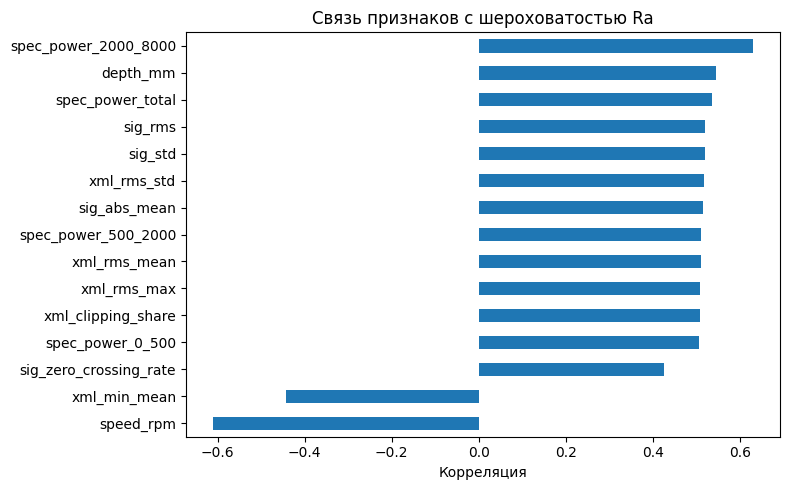

In [5]:
numeric_features = features.select_dtypes(include="number")
correlations = (
    numeric_features.corr(numeric_only=True)["roughness_ra"]
    .drop("roughness_ra")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Топ-15 признаков по модулю корреляции с roughness_ra:")
display(correlations.head(15).to_frame("corr_with_roughness_ra"))

plt.figure(figsize=(8, 5))
correlations.head(15).sort_values().plot(kind="barh")
plt.title("Связь признаков с шероховатостью Ra")
plt.xlabel("Корреляция")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_correlations.png", dpi=150)
plt.show()

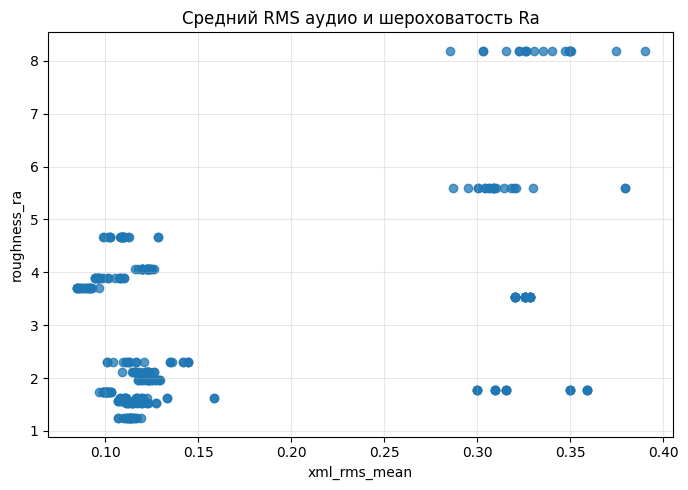

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(features["xml_rms_mean"], features["roughness_ra"], alpha=0.75)
plt.title("Средний RMS аудио и шероховатость Ra")
plt.xlabel("xml_rms_mean")
plt.ylabel("roughness_ra")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "rms_vs_roughness.png", dpi=150)
plt.show()

## 5. Результат этапа

Второй этап завершен: акустические и технологические признаки сохранены в `data/processed/features.csv`. Следующий этап - обучение моделей и оценка точности прогноза `Ra`.
